In [1]:
%matplotlib inline
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import heapq
import random

### 1. Warehouse Map

- กำหนดโครงสร้างแผนที่ตารางกริดของคลังสินค้า

In [2]:
warehouse = np.array([
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0]
])

### 2. Coordinate Validation

- ตรวจสอบความถูกต้องของตำแหน่งทางเข้า ทางออก และชั้นวางสินค้า

In [3]:
def validate_points(warehouse, entrance, exit_point, pickup_points):
    if warehouse[entrance] != 0: raise ValueError("Entrance must be on walkway (0)")
    if warehouse[exit_point] != 0: raise ValueError("Exit must be on walkway (0)")
    for point in pickup_points:
        if warehouse[point] != 1: raise ValueError(f"Pickup point {point} must be on shelf (1)")

### 3. Random Pickup Point Generation

- สุ่มจุดหยิบสินค้าตามจำนวนที่ต้องการพร้อมล็อกค่า seed

In [4]:
def generate_pickup_points(warehouse, n, seed=42):
    shelf_positions = list(zip(*np.where(warehouse == 1)))
    rng = np.random.default_rng(seed)
    selected_indices = rng.choice(len(shelf_positions), size=n, replace=False)
    return [shelf_positions[index] for index in selected_indices]

### 4. Warehouse Map Visualization

- ฟังก์ชันแปลงข้อมูลเป็นภาพกราฟิก

In [5]:
def plot_warehouse(warehouse, entrance, exit_point, pickup_points):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title("Warehouse Map with Entrance, Exit and Pickup Points", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)
    plt.show()

### 5. Initialize Coordinates and Display Map

- แสดงภาพแผนที่

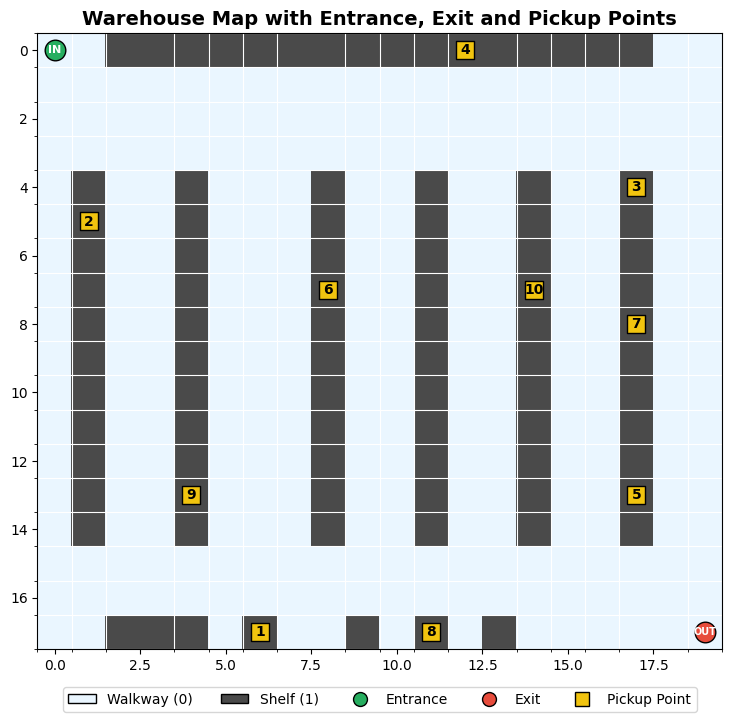

In [6]:
entrance = (0, 0)
exit_point = (17, 19)
n = 10

pickup_points = generate_pickup_points(warehouse=warehouse, n=n, seed=20)

validate_points(warehouse, entrance, exit_point, pickup_points)  
plot_warehouse(warehouse, entrance, exit_point, pickup_points) 

### 6. Print Pickup Coordinates

- แสดงพิกัดตัวเลข (Row, Column) ของจุดหยิบสินค้าทั้งหมด

In [7]:
print("Entrance:", entrance)
print("Exit:", exit_point)
for index, point in enumerate(pickup_points, start=1):
    print(f"  Pickup {index}: ({int(point[0])}, {int(point[1])})")

Entrance: (0, 0)
Exit: (17, 19)
  Pickup 1: (17, 6)
  Pickup 2: (5, 1)
  Pickup 3: (4, 17)
  Pickup 4: (0, 12)
  Pickup 5: (13, 17)
  Pickup 6: (7, 8)
  Pickup 7: (8, 17)
  Pickup 8: (17, 11)
  Pickup 9: (13, 4)
  Pickup 10: (7, 14)


## A* Search Algorithm and Distance Matrix

### 7. Stand Position Finder

- ค้นหาพิกัดจุดยืนหยิบสินค้าที่อยู่ติดกับชั้นวางสินค้า เพื่อเตรียมให้พนักงานยืนหยิบของ

In [8]:
def get_valid_stand_positions(warehouse, item_pos):
    stand_positions = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for dr, dc in directions:
        nr, nc = item_pos[0] + dr, item_pos[1] + dc
        if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
            if warehouse[nr, nc] == 0:
                stand_positions.append((nr, nc))
    return stand_positions

### 8. Shortest Path Calculation

- ใช้ A* Search คำนวณหาเส้นทางและระยะทางที่สั้นที่สุดบนแผนที่ตารางกริดระหว่างจุดเริ่มต้นและจุดหมาย

In [9]:
def a_star_search(warehouse, starts, targets):
    def heuristic(pos):
        return min(abs(pos[0] - t[0]) + abs(pos[1] - t[1]) for t in targets)
    
    pq = []
    visited = set()
    counter = 0 
    for st in starts:
        heapq.heappush(pq, (heuristic(st), 0, counter, st, [st]))
        counter += 1
        
    while pq:
        f, g, _, curr, path = heapq.heappop(pq)
        
        if curr in targets:
            return g, path
            
        if curr in visited:
            continue
        visited.add(curr)
        
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = curr[0] + dr, curr[1] + dc
            if 0 <= nr < warehouse.shape[0] and 0 <= nc < warehouse.shape[1]:
                if warehouse[nr, nc] == 0 and (nr, nc) not in visited:
                    new_g = g + 1
                    new_f = new_g + heuristic((nr, nc))
                    heapq.heappush(pq, (new_f, new_g, counter, (nr, nc), path + [(nr, nc)]))
                    counter += 1
    return float('inf'), []

### 9. Distance Matrix Generator

- ฟังก์ชันรวบรวมโหนดสำคัญทั้งหมด (ทางเข้า, จุดหยิบสินค้า, ทางออก) 

- นำ A* Search มาใช้งานเพื่อคำนวณตารางระยะทางจริงระหว่างทุกๆ จุด

In [10]:
def build_distance_matrix(warehouse, entrance, exit_point, pickup_points):
    all_nodes = [entrance] + pickup_points + [exit_point]
    num_nodes = len(all_nodes)
    dist_matrix = np.zeros((num_nodes, num_nodes))
    valid_positions = []
    
    for i, node in enumerate(all_nodes):
        if i == 0 or i == num_nodes - 1:
            valid_positions.append([node])
        else:
            valid_positions.append(get_valid_stand_positions(warehouse, node))
            
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                dist_matrix[i][j] = 0
            elif i < j:
                dist, _ = a_star_search(warehouse, valid_positions[i], valid_positions[j])
                dist_matrix[i][j] = dist
                dist_matrix[j][i] = dist 
                
    return dist_matrix, valid_positions

### 10. Generate and Display Distance Matrix

- ประมวลผลและแสดงผลตารางระยะทาง (Distance Matrix)

- รูปแบบภาพฮีทแมพ (Heatmap Visualization) 

- เปรียบเทียบระยะทางระหว่างจุดต่างๆ 

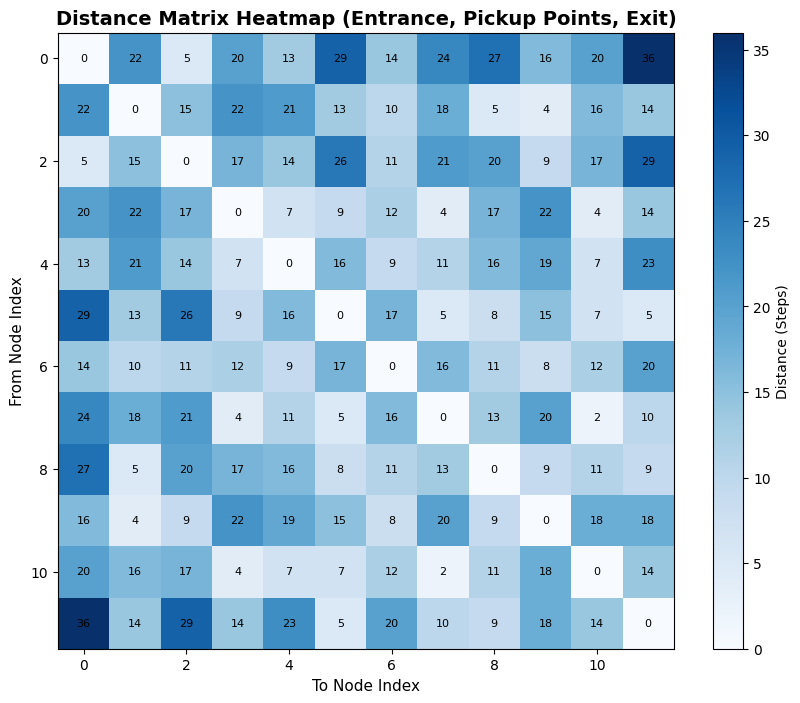

In [11]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)

plt.figure(figsize=(10, 8))
plt.imshow(dist_matrix, cmap="Blues", interpolation="nearest")
plt.colorbar(label="Distance (Steps)")

for i in range(dist_matrix.shape[0]):
    for j in range(dist_matrix.shape[1]):
        plt.text(j, i, f"{int(dist_matrix[i, j])}", ha="center", va="center", color="black", fontsize=8)

plt.title("Distance Matrix Heatmap (Entrance, Pickup Points, Exit)", fontsize=14, fontweight="bold")
plt.xlabel("To Node Index", fontsize=11)
plt.ylabel("From Node Index", fontsize=11)
plt.show()

## Multi-Start 2-Opt Algorithm

### 11. Route Cost Calculator

- คำนวณระยะทางรวมหรือต้นทุนของเส้นทาง (Route Cost) 

- นำค่าระยะทางใน Distance Matrix ของจุดแต่ละจุดเรียงตามลำดับการเดินมาบวกกันตั้งแต่จุดทางเข้าจนถึงจุดทางออก

In [12]:
def calculate_route_cost(route, dist_matrix):
    return sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))

### 12. 2-Opt Optimization Algorithm

- อัลกอริทึมสำหรับปรับปรุงและจัดเรียงลำดับเส้นทาง (Local Search) 

- สลับเส้นเชื่อมเพื่อแก้ไขรอยตัดไขว้กันของเส้นทาง ช่วยให้ระยะทางเดินสั้นขึ้น

In [13]:
def two_opt(route, dist_matrix):
    best_route = route.copy()
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route) - 1):
                if j - i == 1: continue 
                
                current_dist = dist_matrix[best_route[i-1]][best_route[i]] + dist_matrix[best_route[j]][best_route[j+1]]
                new_dist = dist_matrix[best_route[i-1]][best_route[j]] + dist_matrix[best_route[i]][best_route[j+1]]
                
                if new_dist < current_dist:
                    best_route[i:j+1] = best_route[i:j+1][::-1]
                    improved = True
    return best_route

### 13. Multi-Start 2-Opt Optimization

- ฟังก์ชันหลักในการค้นหาเส้นทางที่ดีที่สุด

- สุ่มลำดับจุดเริ่มต้นหลายๆ รอบ (Multi-Start) แล้วนำไปผ่านอัลกอริทึม 2-Opt

- ป้องกันการติดค่าเหมาะสมที่สุดเฉพาะจุด (Local Minimum) 

- หาเส้นทางที่สั้นที่สุดทั่วทั้งแผนที่

In [14]:
def multi_start_2opt(dist_matrix, num_starts=200):
    num_nodes = len(dist_matrix)
    items = list(range(1, num_nodes - 1))
    global_best_route = None
    global_best_cost = float('inf')
    
    for _ in range(num_starts):
        random.shuffle(items)
        initial_route = [0] + items + [num_nodes - 1]
        
        optimized_route = two_opt(initial_route, dist_matrix)
        cost = calculate_route_cost(optimized_route, dist_matrix)
        
        if cost < global_best_cost:
            global_best_cost = cost
            global_best_route = optimized_route
            
    return global_best_route, global_best_cost

### 14. Warehouse Route Path Visualization (Multi-Start 2-Opt)

- ฟังก์ชันสร้างภาพกราฟิกแสดงผลแผนที่คลังสินค้า

In [15]:
def plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, best_distance, stand_points=None):
    rows, cols = warehouse.shape
    colors = ["#EAF6FF", "#4A4A4A"]
    warehouse_cmap = ListedColormap(colors)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(warehouse, cmap=warehouse_cmap, origin="upper", interpolation="nearest")
    
    if full_path:
        path_r = [p[0] for p in full_path]
        path_c = [p[1] for p in full_path]
        plt.plot(path_c, path_r, color="#3498DB", linewidth=3, label="Walking Route", zorder=2)
        
    if stand_points:
        sp_r = [p[0] for p in stand_points]
        sp_c = [p[1] for p in stand_points]
        plt.scatter(sp_c, sp_r, color="#E67E22", s=100, marker='o', edgecolors="white", zorder=4)
    
    plt.scatter(entrance[1], entrance[0], color="#27AE60", s=220, edgecolors="black", zorder=3)
    plt.text(entrance[1], entrance[0], "IN", ha="center", va="center", color="white", fontweight="bold", fontsize=8, zorder=4)
    
    plt.scatter(exit_point[1], exit_point[0], color="#E74C3C", s=220, edgecolors="black", zorder=3)
    plt.text(exit_point[1], exit_point[0], "OUT", ha="center", va="center", color="white", fontweight="bold", fontsize=7, zorder=4)
    
    for index, point in enumerate(pickup_points, start=1):
        plt.scatter(point[1], point[0], color="#F1C40F", s=180, marker="s", edgecolors="black", zorder=3)
        plt.text(point[1], point[0], str(index), ha="center", va="center", fontweight="bold", color="black", zorder=4)

    plt.xticks(np.arange(-0.5, cols, 1), minor=True)
    plt.yticks(np.arange(-0.5, rows, 1), minor=True)
    plt.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    plt.title(f"Warehouse Optimal Routing (Multi-Start 2-Opt)", fontsize=14, fontweight="bold")
    
    legend_elements = [
        Patch(facecolor="#EAF6FF", edgecolor="black", label="Walkway (0)"),
        Patch(facecolor="#4A4A4A", edgecolor="black", label="Shelf (1)"),
        plt.Line2D([0], [0], color="#3498DB", linewidth=3, label="Walking Path"),
        plt.Line2D([0], [0], marker="o", color="w", label="Stand Point", markerfacecolor="#E67E22", markeredgecolor="white", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Entrance", markerfacecolor="#27AE60", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="o", color="w", label="Exit", markerfacecolor="#E74C3C", markeredgecolor="black", markersize=10),
        plt.Line2D([0], [0], marker="s", color="w", label="Pickup Point", markerfacecolor="#F1C40F", markeredgecolor="black", markersize=10)
    ]
    
    plt.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=7)
    plt.show()

### 15. Continuous Path Stitching and Execution (Multi-Start 2-Opt)

- รวบรวมฟังก์ชันหลักมาประมวลผลเพื่อหาลำดับการหยิบสินค้าที่ดีที่สุดจาก Distance Matrix และ Multi-Start 2-Opt

- ใช้เทคนิค Path Stitching นำเส้นทางย่อยที่ได้จาก A* Search มาต่อกัน โดยตั้งเงื่อนไขบังคับให้เริ่มเดินต่อจากพิกัดก้าวสุดท้ายของโหนดก่อนหน้าเสมอ เพื่อแก้ปัญหาการลากเส้นทแยงทะลุชั้นวาง

- คำนวณระยะทางรวมให้ตรงกับจำนวนก้าวเดินจริง

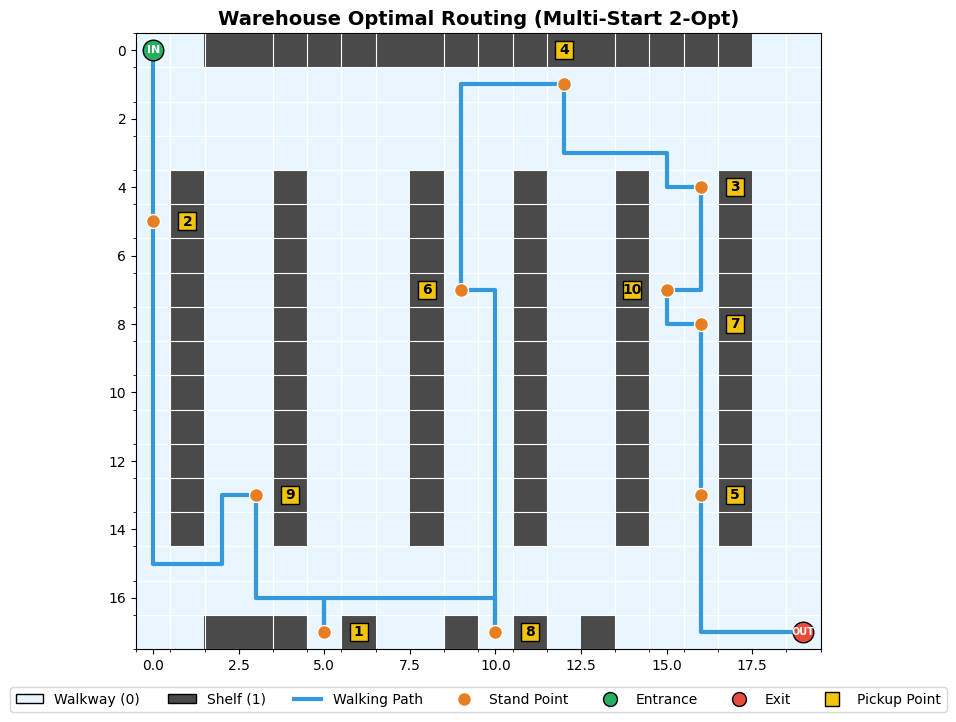

In [16]:
dist_matrix, valid_stands = build_distance_matrix(warehouse, entrance, exit_point, pickup_points)
best_sequence, best_distance = multi_start_2opt(dist_matrix, num_starts=200)

full_path = []
stand_points = [] 

for i in range(len(best_sequence) - 1):
    start_node = best_sequence[i]
    target_node = best_sequence[i+1]
    
    if i == 0:
        starts = valid_stands[start_node]
    else:
        starts = [full_path[-1]]
        
    targets = valid_stands[target_node]
    _, path_segment = a_star_search(warehouse, starts, targets)
    
    if i == 0:
        full_path.extend(path_segment)
    else:
        full_path.extend(path_segment[1:]) 
        
    if i < len(best_sequence) - 2:
        stand_points.append(path_segment[-1])

real_distance = len(full_path) - 1

plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, full_path, real_distance, stand_points)

### 16. Print Minimum Distance Result (Multi-Start 2-Opt)

- แสดงผลลัพธ์ตัวเลขระยะทางที่สั้นที่สุด (MinDistance)

In [17]:
print(f"MinDistance = {real_distance} steps")

MinDistance = 78 steps


## Q-Learning เทียบกับ Multi-Start 2-Opt

ส่วนนี้ใช้ Q-Learning แบบ tabular เพื่อเรียนรู้ลำดับการหยิบสินค้า โดยกำหนด state เป็น (ตำแหน่งปัจจุบัน, ชุดจุดที่หยิบแล้ว) และ action เป็นจุดหยิบที่ยังไม่เคยเยี่ยมชม รางวัลเท่ากับค่าลบของระยะทาง จึงทำให้เอเจนต์พยายามลดระยะทางรวมจากทางเข้าไปยังทางออก.

In [18]:
def q_learning_route(dist_matrix, episodes=15000, alpha=0.15, gamma=1.0,
                     epsilon_start=1.0, epsilon_end=0.02, seed=42):
    # Learn an entrance-to-exit route that visits every pickup node exactly once.
    rng = np.random.default_rng(seed)
    n_nodes = len(dist_matrix)
    pickup_nodes = list(range(1, n_nodes - 1))
    full_mask = (1 << len(pickup_nodes)) - 1
    q, episode_costs = {}, []
    def q_values(state):
        if state not in q:
            q[state] = np.zeros(len(pickup_nodes), dtype=float)
        return q[state]
    for episode in range(episodes):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * (1 - episode / episodes)
        current, mask, total_cost = 0, 0, 0.0
        while mask != full_mask:
            state = (current, mask)
            available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
            values = q_values(state)
            if rng.random() < epsilon:
                action = int(rng.choice(available))
            else:
                best = np.max(values[available])
                action = int(rng.choice([a for a in available if values[a] == best]))
            next_node = pickup_nodes[action]
            step_cost = dist_matrix[current, next_node]
            next_mask = mask | (1 << action)
            reward = -step_cost
            if next_mask == full_mask:
                reward -= dist_matrix[next_node, n_nodes - 1]
                future = 0.0
            else:
                next_available = [a for a in range(len(pickup_nodes)) if not (next_mask & (1 << a))]
                future = np.max(q_values((next_node, next_mask))[next_available])
            values[action] += alpha * (reward + gamma * future - values[action])
            total_cost += step_cost
            current, mask = next_node, next_mask
        episode_costs.append(total_cost + dist_matrix[current, n_nodes - 1])
    current, mask, route = 0, 0, [0]
    while mask != full_mask:
        available = [a for a in range(len(pickup_nodes)) if not (mask & (1 << a))]
        values = q_values((current, mask))
        action = int(available[np.argmax(values[available])])
        current = pickup_nodes[action]
        mask |= 1 << action
        route.append(current)
    route.append(n_nodes - 1)
    return route, calculate_route_cost(route, dist_matrix), episode_costs

def stitch_route(route, warehouse, valid_stands):
    path, stands = [], []
    for i in range(len(route) - 1):
        starts = valid_stands[route[i]] if i == 0 else [path[-1]]
        _, segment = a_star_search(warehouse, starts, valid_stands[route[i + 1]])
        path.extend(segment if i == 0 else segment[1:])
        if i < len(route) - 2:
            stands.append(segment[-1])
    return path, stands, len(path) - 1


### รัน Q-Learning และสร้างตารางเปรียบเทียบ

เพื่อให้เปรียบเทียบอย่างเป็นธรรม ทั้งสองวิธีใช้ distance matrix เดียวกันและมีจุดเริ่ม/จุดจบเหมือนกัน ตารางแสดงทั้งต้นทุนบน matrix และระยะทางเดินจริงหลังเชื่อมเส้นทางด้วย A* บนแผนที่คลังสินค้า.

In [19]:
q_start = time.perf_counter()
q_route, q_matrix_cost, q_episode_costs = q_learning_route(dist_matrix, episodes=60000, seed=42)
q_runtime = time.perf_counter() - q_start
q_full_path, q_stand_points, q_real_distance = stitch_route(q_route, warehouse, valid_stands)
random.seed(42)
two_opt_start = time.perf_counter()
two_opt_route, two_opt_matrix_cost = multi_start_2opt(dist_matrix, num_starts=200)
two_opt_runtime = time.perf_counter() - two_opt_start
two_opt_full_path, two_opt_stands, two_opt_real_distance = stitch_route(two_opt_route, warehouse, valid_stands)
comparison_rows = [
    ("Multi-Start 2-Opt", two_opt_matrix_cost, two_opt_real_distance, two_opt_runtime, two_opt_route),
    ("Q-Learning", q_matrix_cost, q_real_distance, q_runtime, q_route),
]
print(f"{'วิธี':<22} {'ต้นทุน Matrix':>14} {'ระยะจริง (ก้าว)':>17} {'เวลา (วินาที)':>16}  ลำดับโหนด")
print("-" * 100)
for name, matrix_cost, real_cost, runtime, route in comparison_rows:
    print(f"{name:<22} {matrix_cost:>14.0f} {real_cost:>17} {runtime:>16.4f}  {route}")
best_real = min(two_opt_real_distance, q_real_distance)
gap_q = 100 * (q_real_distance - best_real) / best_real
print(f"\nQ-Learning gap จากผลดีที่สุด: {gap_q:.2f}%")


วิธี                    ต้นทุน Matrix   ระยะจริง (ก้าว)    เวลา (วินาที)  ลำดับโหนด
----------------------------------------------------------------------------------------------------
Multi-Start 2-Opt                  66                78           0.0425  [0, 2, 9, 1, 8, 6, 4, 3, 10, 7, 5, 11]
Q-Learning                        116               118          31.3605  [0, 4, 10, 1, 6, 2, 9, 7, 3, 5, 8, 11]

Q-Learning gap จากผลดีที่สุด: 51.28%


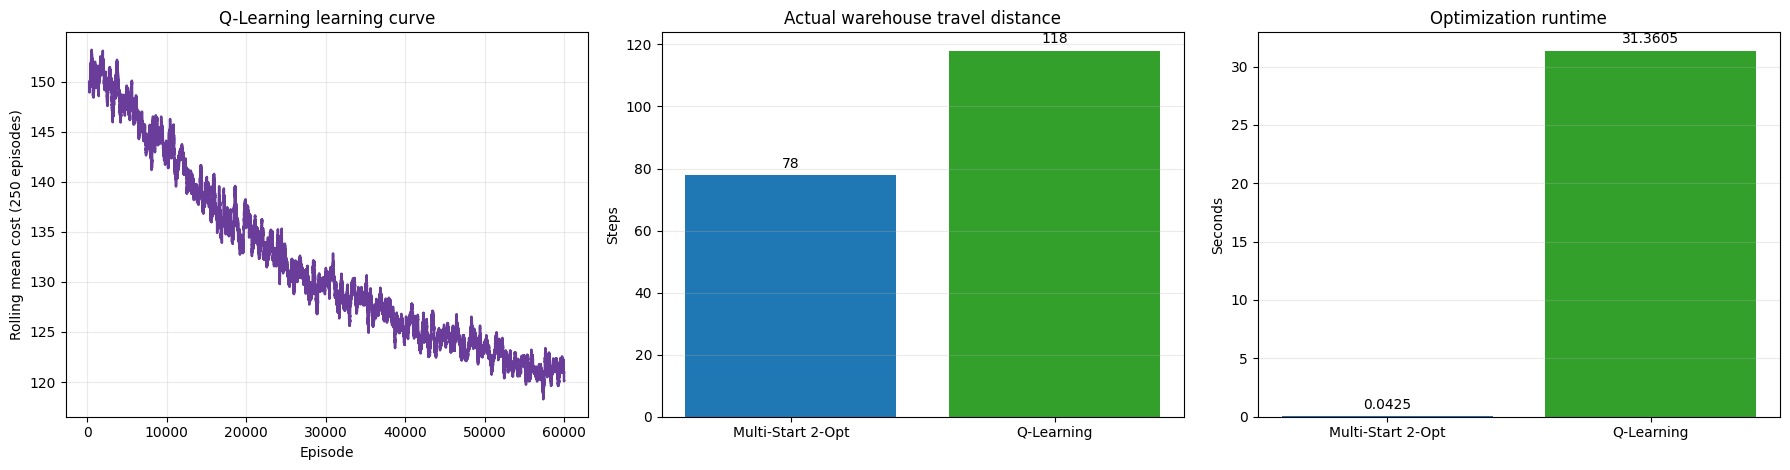

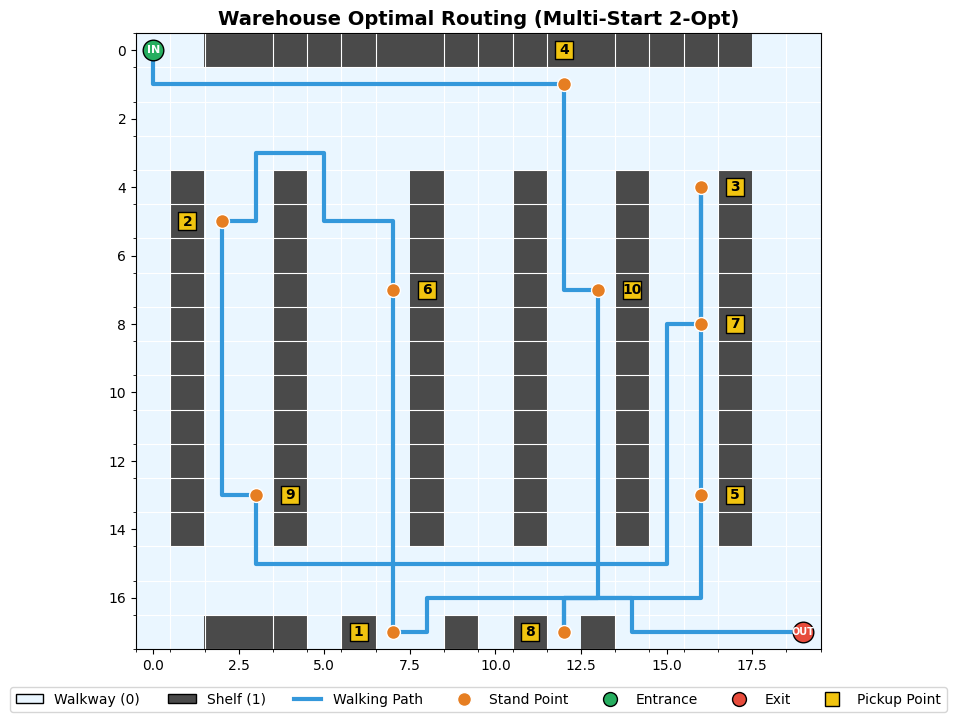

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
window = 250
rolling_cost = np.convolve(q_episode_costs, np.ones(window) / window, mode='valid')
axes[0].plot(np.arange(window, len(q_episode_costs) + 1), rolling_cost, color='#6a3d9a', lw=1.8)
axes[0].set(title='Q-Learning learning curve', xlabel='Episode', ylabel=f'Rolling mean cost ({window} episodes)')
axes[0].grid(alpha=0.25)
methods, colors = ['Multi-Start 2-Opt', 'Q-Learning'], ['#1f78b4', '#33a02c']
bars = axes[1].bar(methods, [two_opt_real_distance, q_real_distance], color=colors)
axes[1].set(title='Actual warehouse travel distance', ylabel='Steps')
axes[1].bar_label(bars, fmt='%.0f', padding=3)
axes[1].grid(axis='y', alpha=0.25)
bars = axes[2].bar(methods, [two_opt_runtime, q_runtime], color=colors)
axes[2].set(title='Optimization runtime', ylabel='Seconds')
axes[2].bar_label(bars, fmt='%.4f', padding=3)
axes[2].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
plot_warehouse_route(warehouse, entrance, exit_point, pickup_points, q_full_path, q_real_distance, q_stand_points)


### สรุปผลการทดลอง

จากการทดลองนี้ **Multi-Start 2-Opt** เป็น baseline ที่แข็งแรงสำหรับปัญหาขนาดเล็ก เพราะค้นหาคำตอบที่ดีได้รวดเร็วจากหลายจุดเริ่มต้น ขณะที่ **Q-Learning** เรียนรู้จากการทดลองซ้ำ ๆ และให้ลำดับเส้นทางที่ใช้ได้จริง แต่ต้องใช้เวลา training มากกว่า

ให้พิจารณาระยะจริง (ก้าว) เป็นตัวชี้วัดหลัก เนื่องจากเป็นระยะทางหลังนำลำดับไปเชื่อมด้วย A* บนทางเดินคลังจริง หาก Q-Learning มี gap ใกล้ 0% แสดงว่าสามารถเรียนรู้นโยบายที่แข่งขันกับ 2-Opt ได้; หาก gap สูงกว่า ควรเพิ่มจำนวน episodes ปรับค่า exploration หรือใช้ 2-Opt เป็นวิธีหลักสำหรับงานวางแผนแบบครั้งเดียว. ในสถานการณ์ที่รูปแบบคำสั่งซื้อหรือสภาพแวดล้อมเปลี่ยนบ่อย Q-Learning มีข้อได้เปรียบเชิงแนวคิด เพราะสามารถฝึกต่อและนำนโยบายเดิมกลับมาใช้ได้.